# Does the concreteness of a concept affect its etymological and semantic structure?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
from selenium import webdriver
from bs4 import BeautifulSoup
from selenium.webdriver.common.by import By
import re
from mpl_toolkits.basemap import Basemap

## 1. Question

In this study, we explore a semantic and typological question: is there a relation between the concreteness of a concept (a concrete concept being something that can directly be perceived in the physical world, as opposed to abstract concepts) and its structural properties in a cross-linguistic semantic database? We focus on two properties: the etymological diversity and the number of semantic neighbours associated with each concept.

For this study, we'll use [𝓔𝓿𝓸Sem](https://evosem.huma-num.fr/index.html) (and more precisely the [𝓔𝓿𝓸Concepts](https://evosem.huma-num.fr/evoconcepts.html) tab), so we first need to understand what data is given to us. 𝓔𝓿𝓸Concepts lets us search by concept, which means we don't look directly at words but rather at semantic meanings. Each concept is expressed by multiple words across the different languages featured in the dataset, and each of these words are associated to one or multiple etyma. The number of etyma associated with a concept (directly shown through 𝓔𝓿𝓸Concepts) will describe how diverse the etymology of this concept is.

Moreover, etyma can be associated with multiple words that do not describe the same concept. We say that this etyma dialexifies the two concepts but also that the two concepts are neighbours. Thus, looking at the amount of neighbours a concept has can give us an idea of how widely distributed are its etyma.

Therefore, we'll test the following two hypothesis:

- Words describing concrete concepts undergo less historical replacement than words describing abstract concepts, therefore **the more concrete a concept is, the lower its etymological diversity will be.**

- Abstract concepts may rely on more restricted or context-dependent lexical material than concrete concepts, therefore **the more concrete a concept is, the more semantic neighbours it will have.**

## 2. Data

To create our main dataset, we used the [Brysbaert 2014 Concreteness](https://norare.clld.org/contributions/Brysbaert-2014-Concreteness) dataset which contains 2585 concepts and how concrete they are (on a scale from 1 to 5 obtained by getting the mean of 4000 votes).

In [9]:
df_concreteness = pd.read_csv("concreteness_concepts.csv")
pd.set_option("display.max_columns", None)

display(df_concreteness)

,concreteness,concept
0,1.19,IF [1459]
1,1.19,PERHAPS [2278]
2,1.19,BELIEF (RELIGIOUS) [3333]
3,1.22,BECAUSE [1157]
4,1.25,HOPE [1092]
...,...,...
2580,5.00,HORN (INSTRUMENT) [939]
2581,5.00,SPEAR [945]
2582,5.00,SEAGULL [950]
2583,5.00,ELBOW [981]


We then search each concept on [𝓔𝓿𝓸Concepts](https://evosem.huma-num.fr/evoconcepts.html) and gathered for each one both the number of etyma associated and the number of dialexified concepts (neighbours).

***The program used to search on 𝓔𝓿𝓸Concepts was made with the help of AI and takes more than an hour to run. For these reasons, it won't be shown in this notebook.***

In [4]:
df = pd.read_csv("evosem_concepts.csv")
pd.set_option("display.max_columns", None)

display(df)

,concreteness,concept,n_etyma,n_neighbours
0,1.19,PERHAPS,18.0,15.0
1,1.22,BECAUSE,44.0,167.0
2,1.25,HOPE,32.0,60.0
3,1.33,ENOUGH,35.0,113.0
4,1.33,UNTIL,29.0,85.0
...,...,...,...,...
2061,5.00,BIRD,121.0,153.0
2062,5.00,SPEAR,76.0,153.0
2063,5.00,SEAGULL,9.0,1.0
2064,5.00,ELBOW,40.0,48.0


Before doing any analysis, let's see the distribution of languages in 𝓔𝓿𝓸Sem. We first get the list of languages scraping [𝓔𝓿𝓸lists](https://evosem.huma-num.fr/language_list.html).

*This part of the program will take around 10 minutes.*

In [ ]:
driver = webdriver.Chrome()

driver.get("https://evosem.huma-num.fr/language_list.html")

links = [
    (a.text, a.get_attribute("href"))
    for a in driver.find_elements(By.CSS_SELECTOR, "p.list_element a.hilite_link") # Gets the list of languages
]

results = []

for name, url in links: # Gets the glottocode of each language
    driver.get(url)
    soup = BeautifulSoup(driver.page_source, "html.parser")
    
    a = soup.find("a", href=re.compile(r"glottolog\.org/resource/languoid/id/")) # Finds the url to glottolog

    code = None

    if a:
        match = re.search(r"/id/([^/]+)", a["href"]) # Finds the id

        if match:
            code = match.group(1)

    results.append((name, code))

print(results)

driver.quit()

[('!Ora', None), ("'Āre'āre", None), ('(head of Hamilton River)', None), ('A-Pucikwar', None), ('Aasax', None), ('Abai Sembuak', None), ('Abaknon', None), ('Abaza', None), ('Abenaki', None), ('Abenlen Ayta', None), ('Abkhaz', None), ('Aborlan Tagbanwa', None), ('Abung', None), ('Acehnese', None), ('Achang (Longchuan)', None), ('Achang', None), ('Achi', None), ('Adi', None), ('Adnyamathanha', None), ('Adonara', None), ('Adyghe', None), ('Adzera', None), ('Aequian', None), ('Afade', None), ('Afar', None), ('Afrikaans', None), ('Aghu Tharnggalu', None), ('Aghu Tharrnggala', None), ('Aghul', None), ('Aghwan', 'aghw1237'), ('Agta (Central Cagayan)', None), ('Agta (Dupaningan)', None), ('Agta (Eastern)', None), ('Agutaynen', None), ('Ahi', None), ('Ahom', 'ahom1240'), ('Ahtna', None), ('Ahus', None), ('Ai-Cham', None), ('Aimol', None), ('Ainu', None), ('Aiton', None), ('Aiwoo', None), ('Aka (Central Africa)', None), ('Aka [Hruso]', None), ('Aka-Bea', None), ('Aka-Cari', None), ('Aka-Kede', N

We'll use [Glottolog](https://glottolog.org/glottolog/language) to get the coordinates of languages.

In [18]:
df_glotto = pd.read_csv("glottolog.csv")
pd.set_option("display.max_columns", None)

display(df_glotto)

,glottocode,name,isocodes,level,macroarea,latitude,longitude
0,3adt1234,3Ad-Tekles,NaN,dialect,Africa,NaN,NaN
1,aala1237,Aalawa,NaN,dialect,Papunesia,NaN,NaN
2,aant1238,Aantantara,NaN,dialect,Papunesia,NaN,NaN
3,aari1239,Aari,aiw,language,Africa,5.95034,36.5721
4,aari1240,Aariya,aay,language,Eurasia,NaN,NaN
...,...,...,...,...,...,...,...
21952,zuwa1238,Zuwadza,NaN,dialect,Papunesia,NaN,NaN
21953,zwal1238,Zwall,NaN,dialect,Africa,NaN,NaN
21954,zyph1238,Zyphe,zyp,language,Eurasia,22.52400,93.2640
21955,zyud1238,Zyuzdin,NaN,dialect,Eurasia,NaN,NaN


We're restricting ourselves to languages present in 𝓔𝓿𝓸Sem. In reality, 𝓔𝓿𝓸Sem has 3335 languages but our code missed some (due to html or name irregularities).

In [ ]:
lang_names = set([lang[0] for lang in results])
lang_codes = set([lang[1] for lang in results])

df_glotto['evosem'] = df_glotto.apply(lambda row: row['name'] in lang_names or row['glottocode'] in lang_codes, axis=1) # We keep the language if we can recognize its name or id
df_evolang = df_glotto[df_glotto['evosem'] == True]

display(df_evolang)
df_evolang['isocodes'].nunique() # Number of distinct languages

,glottocode,name,isocodes,level,macroarea,latitude,longitude,evosem
5,aasa1238,Aasax,aas,language,Africa,-4.006790,36.864800,True
28,abaz1241,Abaza,abq,language,Eurasia,44.250000,42.000000,True
38,aben1249,Abenlen Ayta,abp,language,Papunesia,15.413100,120.200000,True
48,abkh1244,Abkhaz,abk,language,Eurasia,43.056218,41.159115,True
79,achi1257,Acehnese,ace,language,Papunesia,3.907570,96.603200,True
...,...,...,...,...,...,...,...,...
21879,zigu1242,Zigula,NaN,dialect,Africa,-5.618640,38.411400,True
21920,zoog1238,Zoogocho Zapotec,zpq,language,North America,17.201600,-96.343300,True
21926,zouu1235,Zou,zom,language,Eurasia,24.064900,93.925300,True
21936,zulg1242,Zulgo-Gemzek,gnd,language,Africa,10.827000,14.057800,True


1825

We will now map these languages.

In [ ]:
df_evomap = df_evolang.dropna(subset=['latitude', 'longitude'])
df_evomap['isocodes'].nunique() # Number of distinct languages we can map 

1791

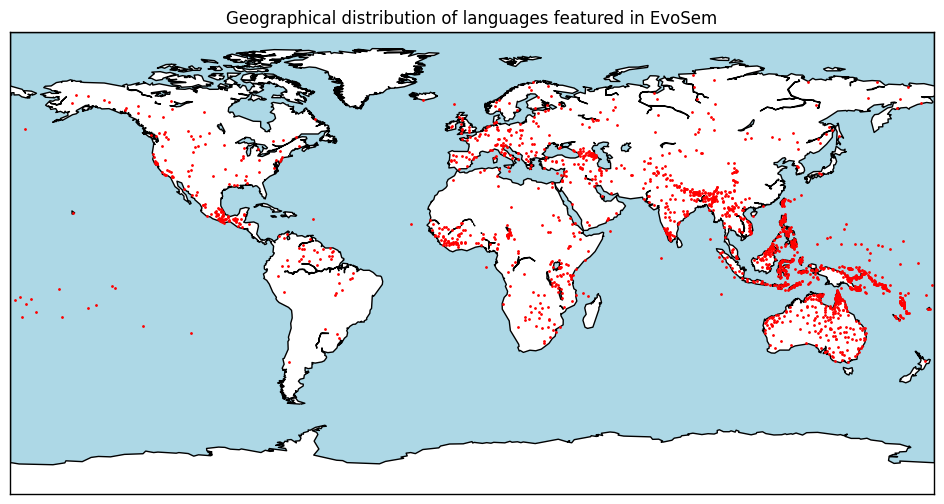

In [ ]:
x_all = df_evomap['longitude'].values # Preparing the points we want to place
y_all = df_evomap['latitude'].values

plt.figure(figsize=(12, 6))

m = Basemap(projection='cyl',
            lat_0=0,
            lon_0=0,
            resolution='c')

m.drawmapboundary(fill_color='lightblue') # Sea/ocean color
m.drawcoastlines(color='black')
m.fillcontinents(color='white',
                 lake_color='lightblue',
                 alpha=1)

m.plot(x_all, y_all, 'ro', markersize=1) # Placing the points

plt.title("Geographical distribution of languages featured in EvoSem")

plt.show()

Now that we have a general view of the dataset, we are going to focus on our variables.

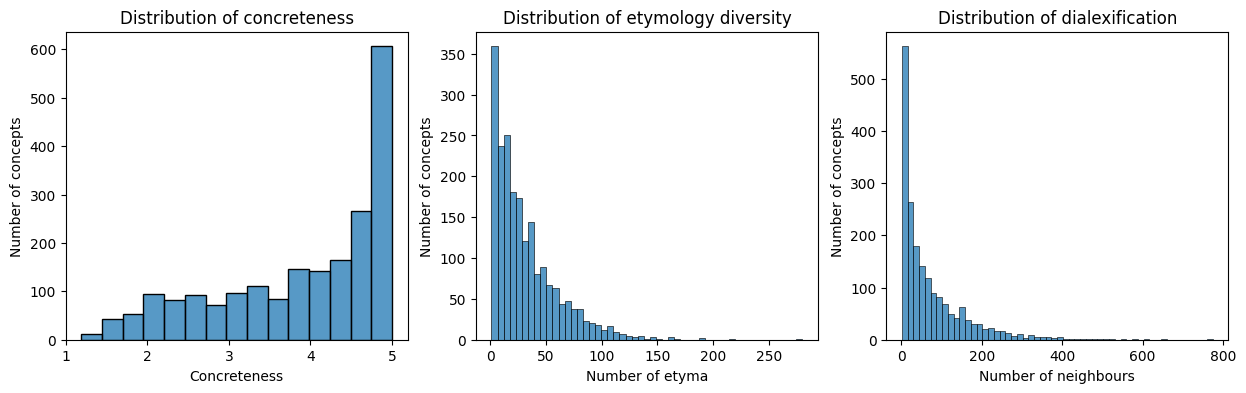

In [ ]:
plt.figure(figsize = (15, 4)) # Overall size

plt.subplot(1, 3, 1) # First subplot
sns.histplot(df['concreteness'])
plt.gca().set_xlabel("Concreteness")
plt.gca().set_ylabel("Number of concepts")
plt.title("Distribution of concreteness")

plt.subplot(1, 3, 2) # Second subplot
sns.histplot(df['n_etyma'])
plt.gca().set_xlabel("Number of etyma")
plt.gca().set_ylabel("Number of concepts")
plt.title("Distribution of etymology diversity")

plt.subplot(1, 3, 3) # Third subplot
sns.histplot(df['n_neighbours'])
plt.gca().set_xlabel("Number of neighbours")
plt.gca().set_ylabel("Number of concepts")
plt.title("Distribution of dialexification")

plt.show()

As you can see, there are a lot more concepts with a very low number of etyma and neighbours. For this reason, we're going to use a logarithmic transformation.

In [ ]:
df['log_n_etyma'] = np.log1p(df['n_etyma']) # log1p applies a logarithmic transformation to the column and handles 0s by doing log(1 + x) instead of log(x)
df['log_n_neighbours'] = np.log1p(df['n_neighbours'])

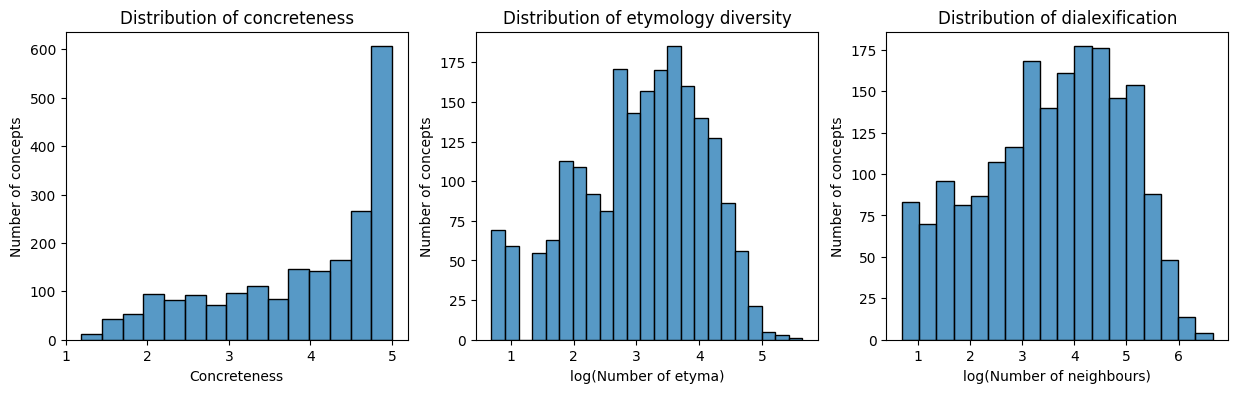

In [41]:
plt.figure(figsize = (15, 4))

plt.subplot(1, 3, 1)
sns.histplot(df['concreteness'])
plt.gca().set_xlabel("Concreteness")
plt.gca().set_ylabel("Number of concepts")
plt.title("Distribution of concreteness")

plt.subplot(1, 3, 2)
sns.histplot(df['log_n_etyma'])
plt.gca().set_xlabel("log(Number of etyma)")
plt.gca().set_ylabel("Number of concepts")
plt.title("Distribution of etymology diversity")

plt.subplot(1, 3, 3)
sns.histplot(df['log_n_neighbours'])
plt.gca().set_xlabel("log(Number of neighbours)")
plt.gca().set_ylabel("Number of concepts")
plt.title("Distribution of dialexification")

plt.show()

## 3. Analysis

Let's test our first hypothesis with a simple linear regression. Is the concreteness of a concept correlated with its number of etyma?

In [ ]:
model_etyma = smf.ols(formula = 'log_n_etyma ~ concreteness', data = df).fit() # We create our model
print(model_etyma.summary()) # We display the results

print(f"p ≈ {model_etyma.pvalues['concreteness']}") # p-value (is the effect statistically significant?)
print(f"b = {model_etyma.params['concreteness']}") # coefficient (how does the variable impact the other)
print(f"Standard Error = {model_etyma.bse['concreteness']}") # standard error (how reliable is the relation)

print(f"R² = {model_etyma.rsquared}") # R-squared (how well does it explain the distribution)

                            OLS Regression Results                            
Dep. Variable:            log_n_etyma   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     101.3
Date:                Sat, 30 May 2026   Prob (F-statistic):           2.72e-23
Time:                        20:09:08   Log-Likelihood:                -2918.7
No. Observations:                2066   AIC:                             5841.
Df Residuals:                    2064   BIC:                             5853.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.8765      0.086     45.267   

Our results show that our two variables are indeed correlated (p < 0.01): the more concrete a concept is, the less etyma it has (b = -0.21). Now that we have tested our hypothesis, let's plot the corresponding graph.

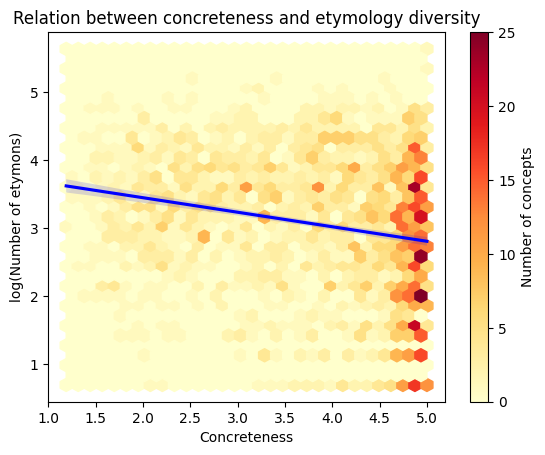

In [ ]:
plt.hexbin(df['concreteness'], df['log_n_etyma'], gridsize=30, cmap='YlOrRd') # For clarity, we group the concepts by hexbin instead of plotting each points
plt.colorbar(label='Number of concepts') 

sns.regplot(x = df['concreteness'], y = df['log_n_etyma'], scatter=False, color='blue') # We plot the regression line
plt.gca().set_xlabel("Concreteness")
plt.gca().set_ylabel("log(Number of etymons)")
plt.title("Relation between concreteness and etymology diversity")

plt.show()

Let's now test our second hypothesis with another simple linear regression. Is the concreteness of a concept correlated with its number of semantic neighbours? 

In [ ]:
model_neighbours = smf.ols(formula = 'log_n_neighbours ~ concreteness', data = df).fit()
print(model_neighbours.summary())

print(f"p ≈ {model_neighbours.pvalues['concreteness']}")
print(f"b = {model_neighbours.params['concreteness']}")
print(f"Standard Error = {model_neighbours.bse['concreteness']}")

print(f"R² = {model_neighbours.rsquared}")

                            OLS Regression Results                            
Dep. Variable:       log_n_neighbours   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     254.8
Date:                Sat, 30 May 2026   Prob (F-statistic):           5.95e-54
Time:                        20:56:38   Log-Likelihood:                -3222.2
No. Observations:                1916   AIC:                             6448.
Df Residuals:                    1914   BIC:                             6460.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        5.2937      0.114     46.363   

Our results show that our two variables are indeed correlated (p < 0.01): the more concrete a concept is, the less neighbours it has (b = -0.46). Now that we have tested our hypothesis, let's plot the corresponding graph.

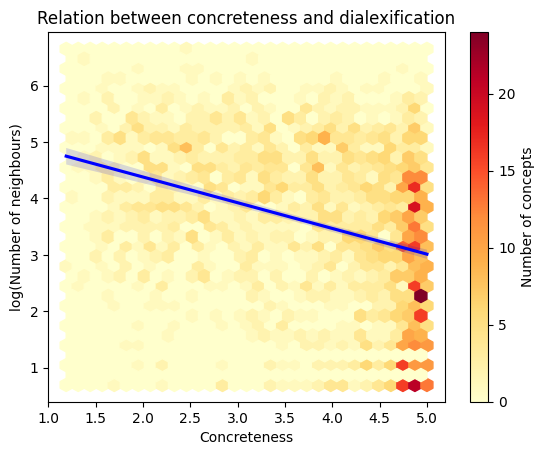

In [78]:
plt.hexbin(df['concreteness'], df['log_n_neighbours'], gridsize=30, cmap='YlOrRd')
plt.colorbar(label='Number of concepts')

sns.regplot(x = df['concreteness'], y = df['log_n_neighbours'], scatter=False, color='blue')
plt.gca().set_xlabel("Concreteness")
plt.gca().set_ylabel("log(Number of neighbours)")
plt.title("Relation between concreteness and dialexification")

plt.show()

## 4. Conclusion

To conclude, thanks to [𝓔𝓿𝓸Sem](https://evosem.huma-num.fr/index.html) data, we have found that the more concrete a concept is, the lower its etymological diversity will be (calculated by the number of etyma), just as we predicted. However, our second hypothesis has been falsified: the more concrete a concept is, the ***less*** semantic neighbours it will have.

Taken together, these findings suggest that concrete concepts occupy more stable and more locally constrained positions within the cross-linguistic semantic–etymological space. In contrast, abstract concepts appear to be associated with greater etymological diversity and higher connectivity, which may reflect a broader distribution of their lexical sources across concepts.

Carefull readers should keep in mind the limitations of this study:
- Our study shows a correlation, not a causal link.
- The concreteness database was made by english speakers, which could impact how they view the concreteness of concepts. This could be a problem since our study tries to find a statistical universal, not an english-only property.
- Since we are using concepts instead of words, we can't easily verify whether or not the effects found do reflect semantic structure. For example, the effects found could be a result of lexical frequency distributions or the Zipf's Law.